#### EXPLORATORY PYTHON ANALYSIS FOR THE CHINA METHANE INFRASTRUCTURE MAPPING PROJECT
##### Using Mike's code to try and load in MethaneSAT Scenes / OSM Polygons

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import hashlib
import osmnx as ox
import importlib
import os
from shapely import wkt
import contextily as ctx
import matplotlib.pyplot as plt
from pyrosm import OSM

AF-1 Kaya
AF-14 Seno
AF-22 Koromije
AF-26 Gharbia
AF-36 Bara
AF-4 Hareto
AF-9 Migori
AMU-DAR'YA: 1
AMU-DAR'YA: 2
AMU-DAR'YA: 3
AMU-DAR'YA: 4
ANADARKO: 1
ANADARKO: 2
APPALACHIAN: 1
APPALACHIAN: 2
APPALACHIAN: 3
APPALACHIAN: 4
ARKOMA FAYETVILLE: 1
ARKOMA WOODFORD-CANEY: 1
AS-0 Shikarpur
AS-20 Muzaffargarh
AS-5 Khyber
ASSAM: 1
Aire sur l'Adour
Anmyeondo Korea
BAC BO - YINGGEHAI: 1
BAKKEN-TORQUAY: 1
BAKKEN-TORQUAY: 2
BAKKEN: 1
BARNETT: 1
BEIBU GULF: 1
BENGAL DELTA SUB-BASIN - BENGAL: 1
BINTUNI: 1
BOWEN - SURAT: 1
BOWEN - SURAT: 2
BOWEN - SURAT: 3
BROWSE: 1
BURGOS BASIN: 1
Backup-1
Backup-2
Backup-3
Backup-4
Backup-5
Backup-6
Boston
Bowen-Surat-1
Bremen Germany
Burgos Philippines
CAMPOS: 1
CENTRAL AFRICAN RIFT: 1
CENTRAL EUROPEAN: 1
CENTRAL GRABEN: 1
CENTRAL PLAINS: 1
CENTRAL SUB-BASIN - WEST SIBERIA: 1
CENTRAL SUB-BASIN - WEST SIBERIA: 10
CENTRAL SUB-BASIN - WEST SIBERIA: 11
CENTRAL SUB-BASIN - WEST SIBERIA: 12
CENTRAL SUB-BASIN - WEST SIBERIA: 13
CENTRAL SUB-BASIN - WEST SIBERIA: 14
CENTR

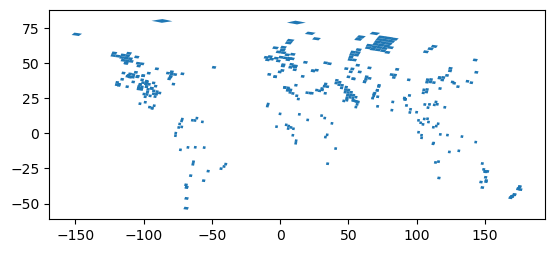

In [2]:
# Load the dataset

##MethaneSAT Scenes
msat_scenes = gpd.read_file("Data/msat_all_scenes.gpkg")

#print(msat_scenes)
#print(msat_scenes.crs)           
#print(msat_scenes.columns)     
#print(msat_scenes.geom_type.unique())  
#msat_scenes["type"].value_counts()

msat_scenes.plot()
for value in sorted(msat_scenes['name']):
    print(value)
##Read in the PRE-SAVED geopackages
##Replace with relative filepaths to each file
#osm_ordos_industrial12 = gpd.read_file("data/osm_polygons/ordos12_dissolved.gpkg")
#osm_ordos_industrial3 = gpd.read_file("data/osm_polygons/ordos3_osm_dissolved.gpkg")
#osm_northchina_industrial = gpd.read_file("data/osm_polygons/NorthChina_OSM_Dissolved.gpkg")
#songliao_facilities = gpd.read_file("data/osm_polygons/songliao_facilities_polygon.gpkg")

In [3]:
##Selecting specific methaneSAT scenes
##Returns geodataframe with only 1 polygon, the scene of interest

ordos1 = msat_scenes[msat_scenes['name']=="ORDOS: 1"]
ordos2 = msat_scenes[msat_scenes['name']=="ORDOS: 2"]
ordos3 = msat_scenes[msat_scenes['name']=="ORDOS: 3"]
tarim1 = msat_scenes[msat_scenes['name']=="TARIM: 1"]
tarim2 = msat_scenes[msat_scenes['name']=="TARIM: 2"]
tarim3 = msat_scenes[msat_scenes['name']=="TARIM: 3"]
junggar = msat_scenes[msat_scenes['name']=="JUNGGAR: 1"]
sichuan1 = msat_scenes[msat_scenes['name']=="SICHUAN: 1"]
sichuan2 = msat_scenes[msat_scenes['name']=="SICHUAN: 2"]
sichuan3 = msat_scenes[msat_scenes['name']=="SICHUAN: 3"]
sichuan4 = msat_scenes[msat_scenes['name']=="SICHUAN: 4"]
songliao1 = msat_scenes[msat_scenes['name']=="SONGLIAO: 1"]
songliao2 = msat_scenes[msat_scenes['name']=="SONGLIAO: 2"]
northchina1 = msat_scenes[msat_scenes['name']=="NORTH CHINA: 1"]
northchina2 = msat_scenes[msat_scenes['name']=="NORTH CHINA: 2"]
northchina3 = msat_scenes[msat_scenes['name']=="NORTH CHINA: 3"]
northchina4 = msat_scenes[msat_scenes['name']=="NORTH CHINA: 4"]



china_msat_scenes = [ordos1, ordos2, ordos3, tarim1, tarim2, tarim3, junggar, sichuan1, sichuan2, sichuan3, sichuan4, 
                     songliao1, songliao2, northchina1, northchina2, northchina3, northchina4]
china_msat_scenes_gdf = gpd.GeoDataFrame(pd.concat(china_msat_scenes, ignore_index=True))


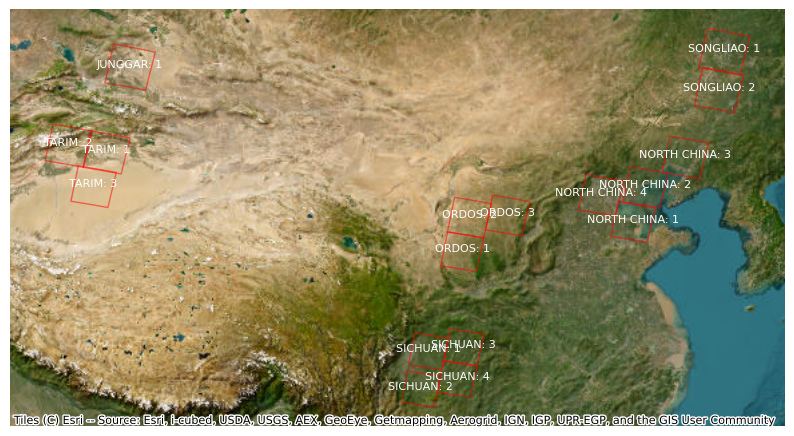

In [4]:
# Plotting MethaneSAT scenes of interest w satellite basemap using contextily
fig, ax = plt.subplots(figsize=(10, 10))

# Plotting
china_msat_epsg3857 = china_msat_scenes_gdf.to_crs(epsg=3857)
china_msat_epsg3857.plot(ax=ax, alpha=0.5, edgecolor='red', facecolor='none')

# Labels
for idx, row in china_msat_epsg3857.iterrows():
    ax.annotate(text=row['name'], xy=(row.geometry.centroid.x, row.geometry.centroid.y), fontsize=8, color='white', ha='center')

# Add satellite basemap
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery)
ax.set_axis_off()
plt.show()

In [ ]:
# Mike's OSM Query
## Alonso's notes -- this querying process is extremely time intensive

##dictionary of tags for query, can be modified
tags = {
    'building': 'industrial',
    'landuse':'industrial',
    'man_made':'works'
} 
ox.settings.timeout = 3000
ox.settings.requests_timeout = 3000
ox.settings.overpass_url = "https://overpass.kumi.systems/api/interpreter"

##Selecting arbitrary geography to run OSM query

songliao1_polygon = songliao1['geometry'].union_all()
songliao1_industrial = ox.features_from_polygon(songliao1_polygon, tags)


#writing to both a geopackage and xlsx file
songliao1_industrial.to_file("Data/Individual_Scene_Facilities/songliao1_industrial.gpkg", driver="GPKG")
#songliao1_industrial.to_excel('songliao1.xlsx')

In [ ]:
# Alonso's alternative -- this downloads the data locally using pyrosm and makes fetching quicker.. marginally
# Using Songliao as the bounding box for the PBF query 
songliao1_polygon = songliao1['geometry'].union_all()

# Change out the local file path to the PBF file here
osm = OSM("Data/china_OSM_2026_06_02_geofabrik.osm.pbf", bounding_box=songliao1_polygon)

# dictionary of tags for query, can be modified
tags = {
    'building': 'industrial',
    'landuse':'industrial',
    'man_made':'works'
} 
# Using get_data_by_custom_criteria for industrial tags
print("Querying features...")
songliao1_industrial = osm.get_data_by_custom_criteria(
    custom_filter=tags,
    filter_type="keep",       # keep only features matching the filter
    keep_nodes=False,         # skip points, only want polygons
    keep_ways=True,           # ways = polygons/lines
    keep_relations=True)      # relations = complex polygons


# Saving immediately to a geopackage
songliao1_industrial.to_file("Data/Individual_Scene_Facilities/songliao1_industrial.gpkg", driver="GPKG")
print("Saved!")

Querying features...


c:\Users\alons\.conda\envs\geo01\Lib\site-packages\pyrosm\pyrosm.py:109: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  nodes, ways, relations, node_coordinates = parse_osm_data(
c:\Users\alons\.conda\envs\geo01\Lib\site-packages\pyrosm\pyrosm.py:109: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are se

Features found: 792
Saved!


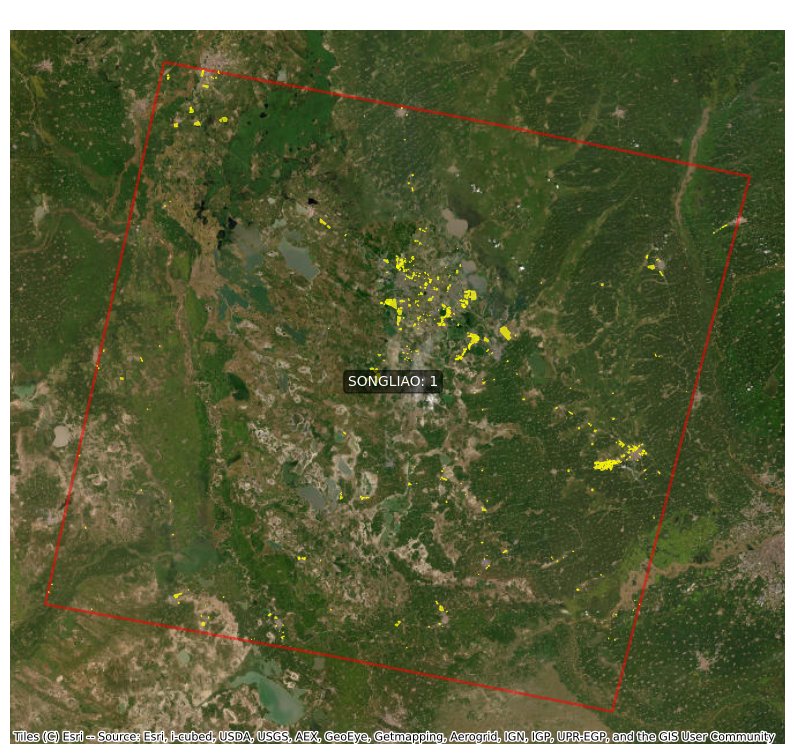

In [5]:
songliao1_industrial = gpd.read_file("Data/Individual_Scene_Facilities/songliao1_industrial.gpkg",
                                     layer = "songliao1_industrial")

# Plotting for inspection
fig, ax = plt.subplots(figsize=(10, 10))

# Convert both layers to EPSG 3857
songliao1_3857 = songliao1.to_crs(epsg=3857)
songliao1_industrial_3857 = songliao1_industrial.to_crs(epsg=3857)

# Plot scene boundary first (bottom layer)
songliao1_3857.plot(ax=ax, alpha=0.5, edgecolor='red', linewidth=2, 
                    facecolor='none')

# Plot industrial features on top
songliao1_industrial_3857.plot(ax=ax, alpha=0.7, edgecolor='yellow', 
                               facecolor='yellow', linewidth=0.5)

# Label the scene
for idx, row in songliao1_3857.iterrows():
    ax.annotate(text=row['name'],
                xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                fontsize=10, color='white', ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.5))

# Satellite basemap
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, zoom=8)
ax.set_axis_off()
ax.set_title("Songliao 1 - Industrial Features", color='white', fontsize=12)
plt.show()

In [ ]:
# Listing layers int he geopackage to confirm dissolved polygons from ArcGIS are there
layers = gpd.list_layers("Data/Individual_Scene_Facilities/songliao1_industrial.gpkg")
print(layers)
# This will be useful as I dissolve geometries, be it here or in ArcGIS Pro


                                        name geometry_type
0             songliao1_industrial_dissolved  MultiPolygon
1  songliao1_industrial_dissolved_attributes  MultiPolygon
2                       songliao1_industrial  MultiPolygon
building
industrial    47
yes            6
Name: count, dtype: int64
landuse
industrial    739
Name: count, dtype: int64


KeyError: 'man_made'